# Experiment 4 — CNN Architectures & Transfer Learning (CIFAR-10)
CS3807 Deep Learning Lab. VGG16 transfer learning + fine-tuning, architecture comparison, hyperparameter study, Adam vs SGD, ResNet50.

**Tip:** set `SUBSET` below to a number (e.g. 10000) to train on a slice of CIFAR-10 for much faster runs.

In [2]:
import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.applications import VGG16, ResNet50
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_pre
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_pre

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

print("GPU:", tf.config.list_physical_devices('GPU'))

GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [3]:
CLASS_NAMES = ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer',
               'Dog', 'Frog', 'Horse', 'Ship', 'Truck']
NUM_CLASSES = 10
OUT_DIR = "outputs_cnn"
os.makedirs(OUT_DIR, exist_ok=True)

# ==== SUBSET CONTROL ====
# None = full dataset (50k train / 10k test).
# Set to e.g. 10000 to use 10k train / 2k test for much faster runs.
SUBSET = 10000

In [4]:
(x_train_raw, y_train), (x_test_raw, y_test) = cifar10.load_data()
y_train, y_test = y_train.flatten(), y_test.flatten()

if SUBSET:
    x_train_raw, y_train = x_train_raw[:SUBSET], y_train[:SUBSET]
    x_test_raw,  y_test  = x_test_raw[:SUBSET//5], y_test[:SUBSET//5]

# Normalize to [0,1] — used by the from-scratch models
x_train = x_train_raw.astype("float32") / 255.0
x_test  = x_test_raw.astype("float32") / 255.0

print("x_train:", x_train.shape)
print("y_train:", y_train.shape)
print("x_test :", x_test.shape)
print("y_test :", y_test.shape)
print("Classes:", NUM_CLASSES)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1982s 12us/step
x_train: (10000, 32, 32, 3)
y_train: (10000,)
x_test : (2000, 32, 32, 3)
y_test : (2000,)
Classes: 10


## Task 1 — Sample images (Plot 1)

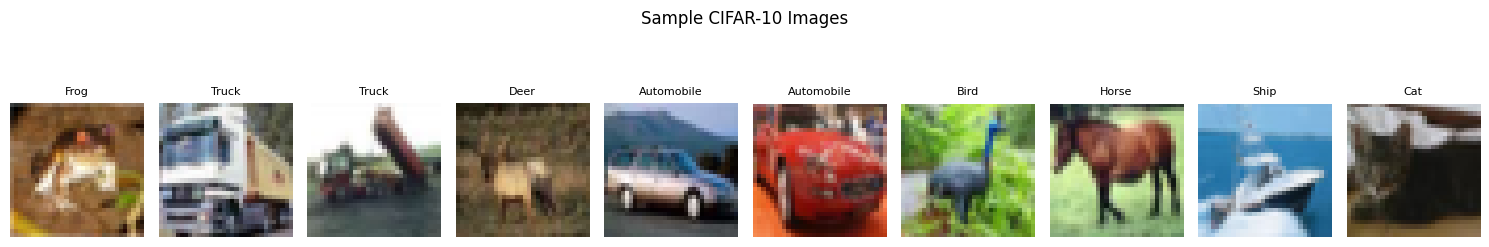

In [5]:
plt.figure(figsize=(15, 3))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(x_train[i])
    plt.title(CLASS_NAMES[y_train[i]], fontsize=8)
    plt.axis('off')
plt.suptitle("Sample CIFAR-10 Images")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/01_samples.png", dpi=120, bbox_inches='tight')
plt.show()

## Task 2 — VGG16 transfer learning: data pipeline

In [6]:
IMG_SIZE = 96
BATCH = 32

def make_ds(x, y, training=False):
    ds = tf.data.Dataset.from_tensor_slices((x, y))
    def _map(img, label):
        img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
        img = vgg_pre(img * 255.0)      # undo /255 then apply vgg preprocess
        return img, label
    if training:
        ds = ds.shuffle(2048)
    ds = ds.map(_map, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(BATCH).prefetch(tf.data.AUTOTUNE)

train_ds = make_ds(x_train, y_train, training=True)
test_ds  = make_ds(x_test,  y_test)
print("Pipelines ready.")

I0000 00:00:1788099052.267163      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1788099052.270042      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Pipelines ready.


### Build VGG16 with frozen base + new classifier head

In [7]:
base = VGG16(weights="imagenet", include_top=False,
             input_shape=(IMG_SIZE, IMG_SIZE, 3))
base.trainable = False        # freeze convolutional base

vgg = models.Sequential([
    base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation="softmax"),
], name="VGG16_transfer")

vgg.compile(optimizer=optimizers.Adam(1e-3),
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy"])
vgg.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "VGG16_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 3, 3, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,586 (56.64 MB)

 Trainable params: 133,898 (523.04 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

## Task 3 — Train the classifier (frozen base)

In [8]:
EPOCHS = 10
t0 = time.time()
hist = vgg.fit(train_ds, validation_data=test_ds, epochs=EPOCHS, verbose=2)
acc_before = vgg.evaluate(test_ds, verbose=0)[1]
print(f"\nTest accuracy BEFORE fine-tuning: {acc_before:.4f}")

Epoch 1/10


I0000 00:00:1788099061.391504     114 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


313/313 - 25s - 81ms/step - accuracy: 0.6410 - loss: 1.5505 - val_accuracy: 0.7430 - val_loss: 0.7737
Epoch 2/10
313/313 - 14s - 46ms/step - accuracy: 0.7778 - loss: 0.6590 - val_accuracy: 0.7695 - val_loss: 0.6972
Epoch 3/10
313/313 - 15s - 47ms/step - accuracy: 0.8311 - loss: 0.4913 - val_accuracy: 0.7885 - val_loss: 0.6512
Epoch 4/10
313/313 - 15s - 48ms/step - accuracy: 0.8665 - loss: 0.3832 - val_accuracy: 0.7845 - val_loss: 0.6718
Epoch 5/10
313/313 - 15s - 49ms/step - accuracy: 0.8888 - loss: 0.3166 - val_accuracy: 0.7810 - val_loss: 0.7085
Epoch 6/10
313/313 - 15s - 49ms/step - accuracy: 0.9092 - loss: 0.2583 - val_accuracy: 0.7875 - val_loss: 0.6949
Epoch 7/10
313/313 - 16s - 51ms/step - accuracy: 0.9226 - loss: 0.2199 - val_accuracy: 0.7830 - val_loss: 0.7137
Epoch 8/10
313/313 - 16s - 52ms/step - accuracy: 0.9316 - loss: 0.1994 - val_accuracy: 0.7900 - val_loss: 0.7687
Epoch 9/10
313/313 - 16s - 52ms/step - accuracy: 0.9376 - loss: 0.1824 - val_accuracy: 0.7870 - val_loss: 0

## Task 4 — Fine-tuning (unfreeze last conv block)

In [9]:
# Unfreeze only the last conv block (block5)
base.trainable = True
for layer in base.layers:
    layer.trainable = layer.name.startswith("block5")

print("Unfrozen layers:", [l.name for l in base.layers if l.trainable])

# Recompile with a lower LR for fine-tuning
vgg.compile(optimizer=optimizers.Adam(1e-4),
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy"])

FT_EPOCHS = 6
hist_ft = vgg.fit(train_ds, validation_data=test_ds, epochs=FT_EPOCHS, verbose=2)
train_time = time.time() - t0
acc_after = vgg.evaluate(test_ds, verbose=0)[1]
print(f"\nAccuracy BEFORE fine-tuning: {acc_before:.4f}")
print(f"Accuracy AFTER  fine-tuning: {acc_after:.4f}")

Unfrozen layers: ['block5_conv1', 'block5_conv2', 'block5_conv3', 'block5_pool']
Epoch 1/6
313/313 - 30s - 97ms/step - accuracy: 0.8244 - loss: 0.5719 - val_accuracy: 0.8175 - val_loss: 0.5735
Epoch 2/6
313/313 - 21s - 68ms/step - accuracy: 0.9070 - loss: 0.2865 - val_accuracy: 0.8320 - val_loss: 0.5429
Epoch 3/6
313/313 - 21s - 68ms/step - accuracy: 0.9461 - loss: 0.1674 - val_accuracy: 0.8655 - val_loss: 0.5143
Epoch 4/6
313/313 - 21s - 67ms/step - accuracy: 0.9598 - loss: 0.1245 - val_accuracy: 0.8380 - val_loss: 0.6639
Epoch 5/6
313/313 - 21s - 67ms/step - accuracy: 0.9650 - loss: 0.1076 - val_accuracy: 0.8350 - val_loss: 0.7284
Epoch 6/6
313/313 - 21s - 67ms/step - accuracy: 0.9741 - loss: 0.0833 - val_accuracy: 0.8570 - val_loss: 0.6043

Accuracy BEFORE fine-tuning: 0.7830
Accuracy AFTER  fine-tuning: 0.8570


In [10]:
# Merge the two training phases for plotting
H = {k: hist.history[k] + hist_ft.history[k]
     for k in ["accuracy", "val_accuracy", "loss", "val_loss"]}
split = len(hist.history["accuracy"])   # epoch where fine-tuning starts

### Plots 2 & 3 — Accuracy

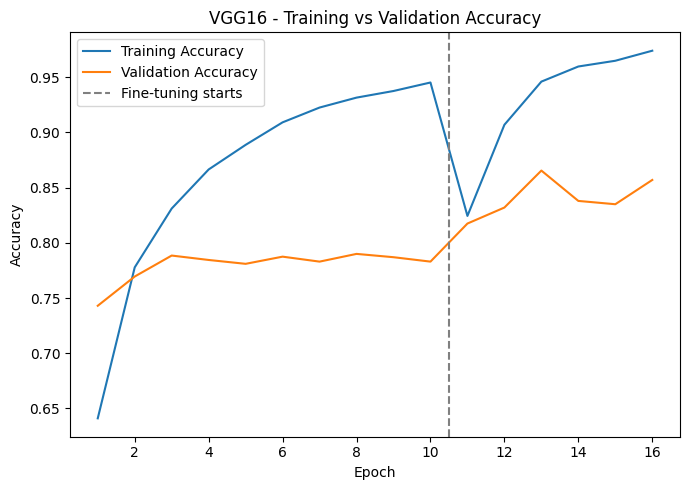

In [11]:
ep = range(1, len(H["accuracy"]) + 1)

plt.figure(figsize=(7, 5))
plt.plot(ep, H["accuracy"], label="Training Accuracy")
plt.plot(ep, H["val_accuracy"], label="Validation Accuracy")
plt.axvline(split + 0.5, ls="--", c="gray", label="Fine-tuning starts")
plt.title("VGG16 - Training vs Validation Accuracy")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend()
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/02_accuracy.png", dpi=120, bbox_inches='tight')
plt.show()

### Plots 4 & 5 — Loss

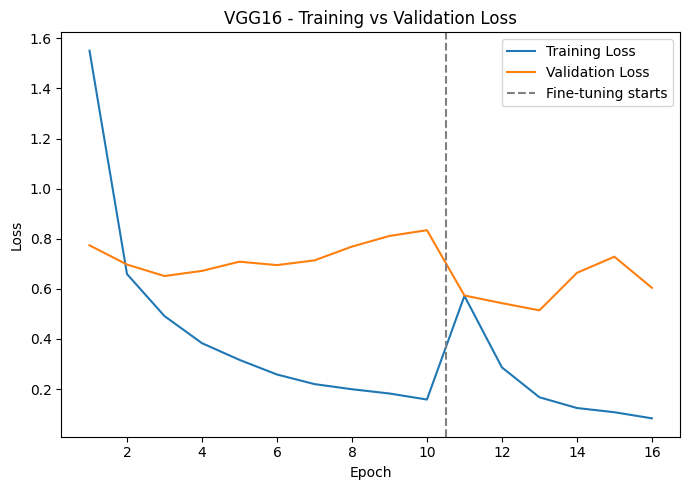

In [12]:
plt.figure(figsize=(7, 5))
plt.plot(ep, H["loss"], label="Training Loss")
plt.plot(ep, H["val_loss"], label="Validation Loss")
plt.axvline(split + 0.5, ls="--", c="gray", label="Fine-tuning starts")
plt.title("VGG16 - Training vs Validation Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend()
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/03_loss.png", dpi=120, bbox_inches='tight')
plt.show()

## Task 5 — Evaluation: metrics + classification report

In [13]:
probs = vgg.predict(test_ds, verbose=0)
y_pred = probs.argmax(axis=1)

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average="macro", zero_division=0)
rec  = recall_score(y_test, y_pred, average="macro", zero_division=0)
f1   = f1_score(y_test, y_pred, average="macro", zero_division=0)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}\n")
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES, zero_division=0))

Accuracy : 0.8570
Precision: 0.8585
Recall   : 0.8555
F1-score : 0.8555

              precision    recall  f1-score   support

    Airplane       0.89      0.72      0.80       196
  Automobile       0.93      0.93      0.93       198
        Bird       0.81      0.81      0.81       195
         Cat       0.77      0.75      0.76       199
        Deer       0.84      0.87      0.86       198
         Dog       0.74      0.84      0.79       185
        Frog       0.90      0.90      0.90       216
       Horse       0.93      0.88      0.90       193
        Ship       0.85      0.93      0.89       217
       Truck       0.92      0.93      0.92       203

    accuracy                           0.86      2000
   macro avg       0.86      0.86      0.86      2000
weighted avg       0.86      0.86      0.86      2000



### Plot 6 — Confusion Matrix

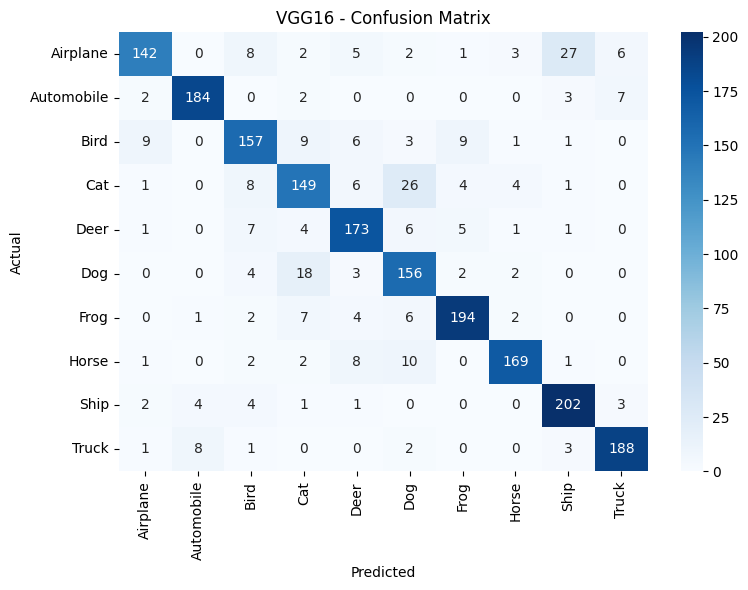

In [14]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("VGG16 - Confusion Matrix")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/04_confmat.png", dpi=120, bbox_inches='tight')
plt.show()

### Plot 7 — Misclassified Images (optional)

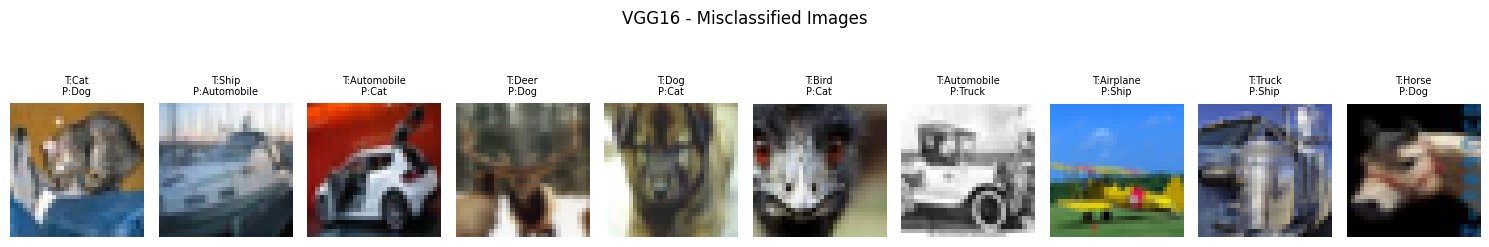

In [15]:
wrong = np.where(y_test != y_pred)[0][:10]
plt.figure(figsize=(15, 3))
for i, idx in enumerate(wrong):
    plt.subplot(1, 10, i+1)
    plt.imshow(x_test[idx])
    plt.title(f"T:{CLASS_NAMES[y_test[idx]]}\nP:{CLASS_NAMES[y_pred[idx]]}", fontsize=7)
    plt.axis('off')
plt.suptitle("VGG16 - Misclassified Images")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/05_misclassified.png", dpi=120, bbox_inches='tight')
plt.show()

## §18.1 — Performance Metrics (VGG16)

In [16]:
train_acc_final = H["accuracy"][-1]
total_params = vgg.count_params()

print("=== 18.1 Performance Metrics (VGG16) ===")
print(f"Training Accuracy : {train_acc_final:.4f}")
print(f"Testing Accuracy  : {acc:.4f}")
print(f"Precision         : {prec:.4f}")
print(f"Recall            : {rec:.4f}")
print(f"F1-score          : {f1:.4f}")
print(f"Training Time     : {train_time:.1f}s")
print(f"Total Parameters  : {total_params:,}")

=== 18.1 Performance Metrics (VGG16) ===
Training Accuracy : 0.9741
Testing Accuracy  : 0.8570
Precision         : 0.8585
Recall            : 0.8555
F1-score          : 0.8555
Training Time     : 303.7s
Total Parameters  : 14,848,586


## §18.2 — Architecture comparison (from-scratch models)
LeNet-5, AlexNet, GoogleNet and ResNet trained from scratch on CIFAR-10 (32x32) for comparison.

In [17]:
def train_scratch(build_fn, name, epochs=8):
    tf.keras.backend.clear_session()
    model = build_fn()
    model.compile(optimizer=optimizers.Adam(1e-3),
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
    t0 = time.time()
    model.fit(x_train, y_train, validation_split=0.1,
              epochs=epochs, batch_size=64, verbose=0)
    dt = time.time() - t0
    test_acc = model.evaluate(x_test, y_test, verbose=0)[1]
    params = model.count_params()
    print(f"{name:<10} params={params:>10,}  acc={test_acc*100:5.2f}%  time={dt:5.1f}s")
    return {"params": params, "acc": test_acc * 100, "time": dt}

In [18]:
# --- LeNet-5 (classic small CNN, adapted to 32x32x3) ---
def build_lenet():
    return models.Sequential([
        layers.Input((32,32,3)),
        layers.Conv2D(6, 5, activation='tanh', padding='same'),
        layers.AveragePooling2D(pool_size=2),
        layers.Conv2D(16, 5, activation='tanh'),
        layers.AveragePooling2D(pool_size=2),
        layers.Flatten(),
        layers.Dense(120, activation='tanh'),
        layers.Dense(84, activation='tanh'),
        layers.Dense(NUM_CLASSES, activation='softmax'),
    ], name="LeNet5")

In [19]:
# --- AlexNet (scaled-down for 32x32) ---
def build_alexnet():
    return models.Sequential([
        layers.Input((32,32,3)),
        layers.Conv2D(64, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(pool_size=2),
        layers.Conv2D(128, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(pool_size=2),
        layers.Conv2D(256, 3, activation='relu', padding='same'),
        layers.Conv2D(256, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(pool_size=2),
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(NUM_CLASSES, activation='softmax'),
    ], name="AlexNet")

In [20]:
# --- GoogleNet: small Inception modules (multi-scale parallel filters) ---
def inception(x, f1, f3, f5, fp):
    b1 = layers.Conv2D(f1, 1, padding='same', activation='relu')(x)
    b3 = layers.Conv2D(f3, 1, padding='same', activation='relu')(x)
    b3 = layers.Conv2D(f3, 3, padding='same', activation='relu')(b3)
    b5 = layers.Conv2D(f5, 1, padding='same', activation='relu')(x)
    b5 = layers.Conv2D(f5, 5, padding='same', activation='relu')(b5)
    bp = layers.MaxPooling2D(3, strides=1, padding='same')(x)
    bp = layers.Conv2D(fp, 1, padding='same', activation='relu')(bp)
    return layers.Concatenate()([b1, b3, b5, bp])

def build_googlenet():
    inp = layers.Input((32,32,3))
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(inp)
    x = layers.MaxPooling2D(pool_size=2)(x)
    x = inception(x, 32, 32, 16, 16)
    x = inception(x, 64, 64, 32, 32)
    x = layers.MaxPooling2D(pool_size=2)(x)
    x = layers.GlobalAveragePooling2D()(x)
    out = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    return models.Model(inp, out, name="GoogleNet")

In [21]:
# --- ResNet: small residual net with skip connections ---
def res_block(x, filters):
    shortcut = x
    y = layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
    y = layers.Conv2D(filters, 3, padding='same')(y)
    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, padding='same')(shortcut)
    y = layers.Add()([shortcut, y])
    return layers.Activation('relu')(y)

def build_resnet():
    inp = layers.Input((32,32,3))
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(inp)
    x = res_block(x, 32);  x = layers.MaxPooling2D(pool_size=2)(x)
    x = res_block(x, 64);  x = layers.MaxPooling2D(pool_size=2)(x)
    x = res_block(x, 128); x = layers.GlobalAveragePooling2D()(x)
    out = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    return models.Model(inp, out, name="ResNet")

In [22]:
# Train the four from-scratch models
scratch_results = []
scratch_results.append(train_scratch(build_lenet,     "LeNet-5"))
scratch_results.append(train_scratch(build_alexnet,   "AlexNet"))
scratch_results.append(train_scratch(build_googlenet, "GoogleNet"))
scratch_results.append(train_scratch(build_resnet,    "ResNet"))

LeNet-5    params=    83,126  acc=42.60%  time= 11.0s
AlexNet    params= 3,063,690  acc=61.70%  time= 21.9s
GoogleNet  params=   106,810  acc=45.20%  time= 27.2s
ResNet     params=   307,978  acc=59.85%  time= 22.0s


In [23]:
# Assemble the full 18.2 table — VGG16 row from transfer learning above
print(f"{'Model':<12}{'Parameters':>14}{'Accuracy (%)':>14}{'Training Time':>16}")
print("-" * 56)
rows = [
    ("LeNet-5",   scratch_results[0]),
    ("AlexNet",   scratch_results[1]),
    ("VGG16",     {"params": total_params, "acc": acc*100, "time": train_time}),
    ("GoogleNet", scratch_results[2]),
    ("ResNet",    scratch_results[3]),
]
for name, r in rows:
    print(f"{name:<12}{r['params']:>14,}{r['acc']:>14.2f}{r['time']:>14.1f}s")

Model           Parameters  Accuracy (%)   Training Time
--------------------------------------------------------
LeNet-5             83,126         42.60          11.0s
AlexNet          3,063,690         61.70          21.9s
VGG16           14,848,586         85.70         303.7s
GoogleNet          106,810         45.20          27.2s
ResNet             307,978         59.85          22.0s


## §16 — Hyperparameter Study
VGG16 transfer learning, frozen base. Short runs (3 epochs) to show trends.

In [24]:
def build_vgg(dense_units=256, dropout=0.3):
    b = VGG16(weights="imagenet", include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
    b.trainable = False
    m = models.Sequential([
        b, layers.GlobalAveragePooling2D(),
        layers.Dense(dense_units, activation="relu"), layers.Dropout(dropout),
        layers.Dense(NUM_CLASSES, activation="softmax"),
    ])
    return m, b

def run_cfg(name, lr=1e-3, batch=32, epochs=3, opt="adam", dense=256, partial=False):
    tf.keras.backend.clear_session()
    m, b = build_vgg(dense_units=dense)
    if partial:
        b.trainable = True
        for l in b.layers: l.trainable = l.name.startswith("block5")
    optimizer = optimizers.Adam(lr) if opt == "adam" else optimizers.SGD(lr, momentum=0.9)
    m.compile(optimizer, "sparse_categorical_crossentropy", metrics=["accuracy"])
    tr = make_ds(x_train, y_train, training=True).unbatch().batch(batch)
    te = make_ds(x_test,  y_test).unbatch().batch(batch)
    t0 = time.time()
    h = m.fit(tr, validation_data=te, epochs=epochs, verbose=0)
    dt = time.time() - t0
    a = max(h.history["val_accuracy"]) * 100
    print(f"{name:<24} val_acc={a:5.2f}%  time={dt:5.1f}s")
    return {"Config": name, "Val Acc (%)": round(a, 2), "Time (s)": round(dt, 1)}

hp_results = []
hp_results.append(run_cfg("Baseline lr1e-3 bs32"))
hp_results.append(run_cfg("LR=1e-4",        lr=1e-4))
hp_results.append(run_cfg("Batch=16",       batch=16))
hp_results.append(run_cfg("Batch=64",       batch=64))
hp_results.append(run_cfg("Optimizer=SGD",  opt="sgd"))
hp_results.append(run_cfg("Dense=128",      dense=128))
hp_results.append(run_cfg("Frozen=Partial", partial=True))

hp_df = pd.DataFrame(hp_results)
print("\n=== §16 Hyperparameter Study ===")
print(hp_df.to_string(index=False))

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


Baseline lr1e-3 bs32     val_acc=77.10%  time= 55.1s
LR=1e-4                  val_acc=71.70%  time= 54.9s
Batch=16                 val_acc=77.80%  time= 53.4s
Batch=64                 val_acc=77.05%  time= 57.3s
Optimizer=SGD            val_acc=77.20%  time= 54.3s
Dense=128                val_acc=77.45%  time= 55.1s
Frozen=Partial           val_acc= 9.95%  time= 70.9s

=== §16 Hyperparameter Study ===
              Config  Val Acc (%)  Time (s)
Baseline lr1e-3 bs32        77.10      55.1
             LR=1e-4        71.70      54.9
            Batch=16        77.80      53.4
            Batch=64        77.05      57.3
       Optimizer=SGD        77.20      54.3
           Dense=128        77.45      55.1
      Frozen=Partial         9.95      70.9


## §20.2 — ResNet50 Transfer Learning

In [25]:
def make_ds_resnet(x, y, training=False):
    ds = tf.data.Dataset.from_tensor_slices((x, y))
    def _map(img, label):
        img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
        img = resnet_pre(img * 255.0)
        return img, label
    if training: ds = ds.shuffle(2048)
    return ds.map(_map, num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH).prefetch(tf.data.AUTOTUNE)

tf.keras.backend.clear_session()
r_train = make_ds_resnet(x_train, y_train, training=True)
r_test  = make_ds_resnet(x_test,  y_test)

rbase = ResNet50(weights="imagenet", include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
rbase.trainable = False
resnet = models.Sequential([
    rbase, layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation="relu"), layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation="softmax"),
])
resnet.compile(optimizers.Adam(1e-3), "sparse_categorical_crossentropy", metrics=["accuracy"])
t0 = time.time()
resnet.fit(r_train, validation_data=r_test, epochs=6, verbose=2)
resnet_time = time.time() - t0
resnet_acc = resnet.evaluate(r_test, verbose=0)[1]
print(f"\nResNet50 transfer-learning test accuracy: {resnet_acc*100:.2f}%  (time {resnet_time:.1f}s)")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/6
313/313 - 31s - 98ms/step - accuracy: 0.7508 - loss: 0.7940 - val_accuracy: 0.7980 - val_loss: 0.5530
Epoch 2/6
313/313 - 8s - 27ms/step - accuracy: 0.8437 - loss: 0.4565 - val_accuracy: 0.8245 - val_loss: 0.4776
Epoch 3/6
313/313 - 8s - 27ms/step - accuracy: 0.8699 - loss: 0.3679 - val_accuracy: 0.8215 - val_loss: 0.5132
Epoch 4/6
313/313 - 8s - 27ms/step - accuracy: 0.8943 - loss: 0.2971 - val_accuracy: 0.8260 - val_loss: 0.5281
Epoch 5/6
313/313 - 8s - 27ms/step - accuracy: 0.9135 - loss: 0.2454 - val_accuracy: 0.8265 - val_loss: 0.5308
Epoch 6/6
313/313 - 8s - 26ms/step - accuracy: 0.9282 - loss: 0.1988 - val_accuracy: 0.8375 - val_loss: 0.5405

ResNet50 transfer-learning test accuracy: 83.75%  (time 72.4s)


## §20.3 — Adam vs SGD

In [26]:
opt_results = []
for opt_name in ["adam", "sgd"]:
    tf.keras.backend.clear_session()
    m, b = build_vgg()
    optimizer = optimizers.Adam(1e-3) if opt_name == "adam" else optimizers.SGD(1e-3, momentum=0.9)
    m.compile(optimizer, "sparse_categorical_crossentropy", metrics=["accuracy"])
    t0 = time.time()
    h = m.fit(train_ds, validation_data=test_ds, epochs=4, verbose=0)
    dt = time.time() - t0
    a = max(h.history["val_accuracy"]) * 100
    opt_results.append((opt_name.upper(), round(a, 2), round(dt, 1)))
    print(f"{opt_name.upper():<6} val_acc={a:5.2f}%  time={dt:5.1f}s")

print("\n=== §20.3 Adam vs SGD ===")
print(f"{'Optimizer':<10}{'Val Acc (%)':<14}{'Time (s)':<10}")
for o, a, t in opt_results:
    print(f"{o:<10}{a:<14}{t:<10}")

ADAM   val_acc=77.60%  time= 70.2s
SGD    val_acc=76.85%  time= 69.7s

=== §20.3 Adam vs SGD ===
Optimizer Val Acc (%)   Time (s)  
ADAM      77.6          70.2      
SGD       76.85         69.7      
